# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import sys

import matplotlib
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from pathlib import Path

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)


print("Current working directory:")
print(Path.cwd())



Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
Pandas: 2.3.3
NumPy: 2.2.6
Matplotlib: 3.10.9
Seaborn: 0.13.2
SciPy: 1.15.3
Scikit-learn: 1.7.2
Current working directory:
E:\Projects\DataMining\notebooks


In [2]:
DATA_PATH = Path("data/raw/data.csv")

print(DATA_PATH.resolve())
print("File exists:", DATA_PATH.exists())

E:\Projects\DataMining\notebooks\data\raw\data.csv
File exists: False


In [3]:
import sys
from pathlib import Path

print("Python executable:")
print(sys.executable)

print("\nWorking directory:")
print(Path.cwd())

Python executable:
E:\Projects\DataMining\.venv\Scripts\python.exe

Working directory:
E:\Projects\DataMining\notebooks


In [4]:
from pathlib import Path
import sys

import matplotlib
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

DATA_PATH = Path("data/raw/data.csv")

print("Python:", sys.version.split()[0])
print("Python path:", sys.executable)
print("Working directory:", Path.cwd())
print("Data file exists:", DATA_PATH.exists())
print("Data path:", DATA_PATH.resolve())

print("\nLibrary versions:")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.10.11
Python path: E:\Projects\DataMining\.venv\Scripts\python.exe
Working directory: E:\Projects\DataMining\notebooks
Data file exists: False
Data path: E:\Projects\DataMining\notebooks\data\raw\data.csv

Library versions:
Pandas: 2.3.3
NumPy: 2.2.6
Matplotlib: 3.10.9
Seaborn: 0.13.2
SciPy: 1.15.3
Scikit-learn: 1.7.2


# Data Mining Course Project

## Stage 1: Initial Data Loading and Inspection

This stage loads the raw dataset and examines its initial structure.

The objectives are to identify the dataset dimensions, column roles,
data types, missing values, target-class distribution, and duplicate
records.

No values are removed, replaced, encoded, or normalized at this stage.

In [5]:
from pathlib import Path

import pandas as pd
from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

TABLES_DIR.mkdir(parents=True, exist_ok=True)


print("Current working directory:")
print(CURRENT_DIR)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nData path:")
print(DATA_PATH)

print("\nData file exists:")
print(DATA_PATH.exists())

Current working directory:
E:\Projects\DataMining\notebooks

Project root:
E:\Projects\DataMining

Data path:
E:\Projects\DataMining\data\raw\data.csv

Data file exists:
True


In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The dataset file was not found.\n"
        f"Checked path: {DATA_PATH}"
    )


df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()

df_raw = df.copy(deep=True)


print("Data loaded successfully.")
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

Data loaded successfully.
Number of rows: 920
Number of columns: 16


In [7]:
print("First five rows:")
display(df_raw.head())

First five rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
EXPECTED_COLUMNS = [
    "id",
    "age",
    "sex",
    "dataset",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalch",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]


actual_columns = df_raw.columns.tolist()

missing_columns = [
    column
    for column in EXPECTED_COLUMNS
    if column not in actual_columns
]

unexpected_columns = [
    column
    for column in actual_columns
    if column not in EXPECTED_COLUMNS
]


print("Actual columns:")
print(actual_columns)

print("\nMissing expected columns:")
print(missing_columns)

print("\nUnexpected columns:")
print(unexpected_columns)


if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

if unexpected_columns:
    print(
        "\nWarning: The dataset contains unexpected columns."
    )
else:
    print("\nColumn validation passed successfully.")

Actual columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Missing expected columns:
[]

Unexpected columns:
[]

Column validation passed successfully.


In [9]:
ID_COLUMN = "id"
TARGET_COLUMN = "num"

FEATURE_COLUMNS = [
    column
    for column in df_raw.columns
    if column not in [ID_COLUMN, TARGET_COLUMN]
]


X_raw = df_raw[FEATURE_COLUMNS].copy()
y_raw = df_raw[TARGET_COLUMN].copy()


print(f"ID column: {ID_COLUMN}")
print(f"Target column: {TARGET_COLUMN}")
print(f"Number of input features: {len(FEATURE_COLUMNS)}")

print("\nFeature columns:")
print(FEATURE_COLUMNS)

ID column: id
Target column: num
Number of input features: 14

Feature columns:
['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [10]:
column_dictionary = pd.DataFrame(
    [
        {
            "column": "id",
            "role": "identifier",
            "conceptual_type": "integer identifier",
            "description": "Unique record identifier",
        },
        {
            "column": "age",
            "role": "feature",
            "conceptual_type": "numeric",
            "description": "Age in years",
        },
        {
            "column": "sex",
            "role": "feature",
            "conceptual_type": "binary categorical",
            "description": "Patient sex",
        },
        {
            "column": "dataset",
            "role": "feature",
            "conceptual_type": "nominal categorical",
            "description": "Dataset collection center",
        },
        {
            "column": "cp",
            "role": "feature",
            "conceptual_type": "nominal categorical",
            "description": "Chest pain type",
        },
        {
            "column": "trestbps",
            "role": "feature",
            "conceptual_type": "numeric",
            "description": "Resting blood pressure",
        },
        {
            "column": "chol",
            "role": "feature",
            "conceptual_type": "numeric",
            "description": "Serum cholesterol",
        },
        {
            "column": "fbs",
            "role": "feature",
            "conceptual_type": "binary categorical",
            "description": "Fasting blood sugar above 120 mg/dl",
        },
        {
            "column": "restecg",
            "role": "feature",
            "conceptual_type": "nominal categorical",
            "description": "Resting electrocardiographic result",
        },
        {
            "column": "thalch",
            "role": "feature",
            "conceptual_type": "numeric",
            "description": "Maximum heart rate achieved",
        },
        {
            "column": "exang",
            "role": "feature",
            "conceptual_type": "binary categorical",
            "description": "Exercise-induced angina",
        },
        {
            "column": "oldpeak",
            "role": "feature",
            "conceptual_type": "numeric",
            "description": "Exercise-induced ST depression",
        },
        {
            "column": "slope",
            "role": "feature",
            "conceptual_type": "categorical",
            "description": "Slope of the peak exercise ST segment",
        },
        {
            "column": "ca",
            "role": "feature",
            "conceptual_type": "discrete numeric",
            "description": "Number of major vessels",
        },
        {
            "column": "thal",
            "role": "feature",
            "conceptual_type": "nominal categorical",
            "description": "Thalassemia test result",
        },
        {
            "column": "num",
            "role": "target",
            "conceptual_type": "multiclass target",
            "description": "Target class from 0 to 4",
        },
    ]
)


display(column_dictionary)

,column,role,conceptual_type,description
0,id,identifier,integer identifier,Unique record identifier
1,age,feature,numeric,Age in years
2,sex,feature,binary categorical,Patient sex
3,dataset,feature,nominal categorical,Dataset collection center
4,cp,feature,nominal categorical,Chest pain type
5,trestbps,feature,numeric,Resting blood pressure
6,chol,feature,numeric,Serum cholesterol
7,fbs,feature,binary categorical,Fasting blood sugar above 120 mg/dl
8,restecg,feature,nominal categorical,Resting electrocardiographic result
9,thalch,feature,numeric,Maximum heart rate achieved


In [11]:
column_profile = pd.DataFrame(
    {
        "column": df_raw.columns,
        "pandas_dtype": [
            str(df_raw[column].dtype)
            for column in df_raw.columns
        ],
        "non_null_count": [
            int(df_raw[column].notna().sum())
            for column in df_raw.columns
        ],
        "missing_count": [
            int(df_raw[column].isna().sum())
            for column in df_raw.columns
        ],
        "missing_percent": [
            round(df_raw[column].isna().mean() * 100, 2)
            for column in df_raw.columns
        ],
        "unique_count": [
            int(df_raw[column].nunique(dropna=True))
            for column in df_raw.columns
        ],
    }
)


column_profile = column_profile.merge(
    column_dictionary[
        [
            "column",
            "role",
            "conceptual_type",
            "description",
        ]
    ],
    on="column",
    how="left",
)


column_profile = column_profile[
    [
        "column",
        "role",
        "pandas_dtype",
        "conceptual_type",
        "non_null_count",
        "missing_count",
        "missing_percent",
        "unique_count",
        "description",
    ]
]


display(column_profile)

,column,role,pandas_dtype,conceptual_type,non_null_count,missing_count,missing_percent,unique_count,description
0,id,identifier,int64,integer identifier,920,0,0.00,920,Unique record identifier
1,age,feature,int64,numeric,920,0,0.00,50,Age in years
2,sex,feature,object,binary categorical,920,0,0.00,2,Patient sex
3,dataset,feature,object,nominal categorical,920,0,0.00,4,Dataset collection center
4,cp,feature,object,nominal categorical,920,0,0.00,4,Chest pain type
5,trestbps,feature,float64,numeric,861,59,6.41,61,Resting blood pressure
6,chol,feature,float64,numeric,890,30,3.26,217,Serum cholesterol
7,fbs,feature,object,binary categorical,830,90,9.78,2,Fasting blood sugar above 120 mg/dl
8,restecg,feature,object,nominal categorical,918,2,0.22,3,Resting electrocardiographic result
9,thalch,feature,float64,numeric,865,55,5.98,119,Maximum heart rate achieved


In [12]:
total_cells = int(df_raw.shape[0] * df_raw.shape[1])
total_missing = int(df_raw.isna().sum().sum())

rows_with_missing = int(
    df_raw.isna().any(axis=1).sum()
)

complete_rows = int(
    df_raw.notna().all(axis=1).sum()
)


print(f"Total cells: {total_cells}")
print(f"Total missing values: {total_missing}")
print(
    "Overall missing percentage: "
    f"{total_missing / total_cells * 100:.2f}%"
)
print(
    "Rows with at least one missing value: "
    f"{rows_with_missing}"
)
print(f"Complete rows: {complete_rows}")

Total cells: 14720
Total missing values: 1759
Overall missing percentage: 11.95%
Rows with at least one missing value: 621
Complete rows: 299


In [13]:
target_distribution = (
    df_raw[TARGET_COLUMN]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("target_class")
    .reset_index(name="count")
)


target_distribution["percent"] = (
    target_distribution["count"]
    / len(df_raw)
    * 100
).round(2)


display(target_distribution)

,target_class,count,percent
0,0,411,44.67
1,1,265,28.80
2,2,109,11.85
3,3,107,11.63
4,4,28,3.04


In [14]:
dataset_distribution = (
    df_raw["dataset"]
    .value_counts(dropna=False)
    .rename_axis("dataset")
    .reset_index(name="count")
)


dataset_distribution["percent"] = (
    dataset_distribution["count"]
    / len(df_raw)
    * 100
).round(2)


display(dataset_distribution)

,dataset,count,percent
0,Cleveland,304,33.04
1,Hungary,293,31.85
2,VA Long Beach,200,21.74
3,Switzerland,123,13.37


In [15]:
duplicate_id_count = int(
    df_raw[ID_COLUMN].duplicated().sum()
)

duplicate_complete_rows = int(
    df_raw.duplicated().sum()
)

duplicate_without_id = int(
    df_raw
    .drop(columns=[ID_COLUMN])
    .duplicated()
    .sum()
)


print(f"Duplicate IDs: {duplicate_id_count}")
print(f"Fully duplicated rows: {duplicate_complete_rows}")
print(
    "Duplicated rows after excluding ID: "
    f"{duplicate_without_id}"
)

Duplicate IDs: 0
Fully duplicated rows: 0
Duplicated rows after excluding ID: 2


In [16]:
observed_target_classes = sorted(
    df_raw[TARGET_COLUMN]
    .dropna()
    .unique()
    .tolist()
)


assert df_raw.shape == (920, 16), (
    "The dataset shape does not match the expected shape."
)

assert len(FEATURE_COLUMNS) == 14, (
    "The dataset must contain 14 input features."
)

assert ID_COLUMN not in X_raw.columns, (
    "The identifier column must not be included in X_raw."
)

assert TARGET_COLUMN not in X_raw.columns, (
    "The target column must not be included in X_raw."
)

assert df_raw[ID_COLUMN].is_unique, (
    "The identifier column contains duplicate values."
)

assert df_raw[TARGET_COLUMN].notna().all(), (
    "The target column contains missing values."
)

assert observed_target_classes == [0, 1, 2, 3, 4], (
    "The observed target classes do not match the expected classes."
)


print("All initial validation checks passed successfully.")

All initial validation checks passed successfully.


In [17]:
column_dictionary.to_csv(
    TABLES_DIR / "01_column_dictionary.csv",
    index=False,
    encoding="utf-8-sig",
)

column_profile.to_csv(
    TABLES_DIR / "01_column_profile.csv",
    index=False,
    encoding="utf-8-sig",
)

target_distribution.to_csv(
    TABLES_DIR / "01_target_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)

dataset_distribution.to_csv(
    TABLES_DIR / "01_dataset_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 1 tables saved successfully.")

for output_file in sorted(TABLES_DIR.glob("01_*.csv")):
    print(output_file)

Stage 1 tables saved successfully.
E:\Projects\DataMining\outputs\tables\01_column_dictionary.csv
E:\Projects\DataMining\outputs\tables\01_column_profile.csv
E:\Projects\DataMining\outputs\tables\01_dataset_distribution.csv
E:\Projects\DataMining\outputs\tables\01_target_distribution.csv


## Stage 2: Descriptive Statistics

This stage calculates descriptive statistics for the numeric input
features.

The calculated measures include count, missing values, mean, median,
minimum, maximum, standard deviation, variance, first quartile, third
quartile, and interquartile range.

No missing values are filled and no observations are removed at this
stage.


In [18]:
NUMERIC_FEATURES = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
]


missing_numeric_features = [
    column
    for column in NUMERIC_FEATURES
    if column not in df_raw.columns
]


if missing_numeric_features:
    raise ValueError(
        f"Numeric features are missing: {missing_numeric_features}"
    )


print("Numeric features:")
print(NUMERIC_FEATURES)

print(f"\nNumber of numeric features: {len(NUMERIC_FEATURES)}")

Numeric features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Number of numeric features: 6


In [19]:
descriptive_statistics = pd.DataFrame(
    index=NUMERIC_FEATURES
)


descriptive_statistics["count"] = (
    df_raw[NUMERIC_FEATURES].count()
)

descriptive_statistics["missing_count"] = (
    df_raw[NUMERIC_FEATURES].isna().sum()
)

descriptive_statistics["missing_percent"] = (
    df_raw[NUMERIC_FEATURES].isna().mean() * 100
)

descriptive_statistics["mean"] = (
    df_raw[NUMERIC_FEATURES].mean()
)

descriptive_statistics["median"] = (
    df_raw[NUMERIC_FEATURES].median()
)

descriptive_statistics["min"] = (
    df_raw[NUMERIC_FEATURES].min()
)

descriptive_statistics["max"] = (
    df_raw[NUMERIC_FEATURES].max()
)

descriptive_statistics["std"] = (
    df_raw[NUMERIC_FEATURES].std(ddof=1)
)

descriptive_statistics["variance"] = (
    df_raw[NUMERIC_FEATURES].var(ddof=1)
)

descriptive_statistics["Q1"] = (
    df_raw[NUMERIC_FEATURES].quantile(0.25)
)

descriptive_statistics["Q3"] = (
    df_raw[NUMERIC_FEATURES].quantile(0.75)
)

descriptive_statistics["IQR"] = (
    descriptive_statistics["Q3"]
    - descriptive_statistics["Q1"]
)

descriptive_statistics["mean_median_difference"] = (
    descriptive_statistics["mean"]
    - descriptive_statistics["median"]
)


descriptive_statistics.index.name = "feature"

display(descriptive_statistics.round(3))

,count,missing_count,missing_percent,mean,median,min,max,std,variance,Q1,Q3,IQR,mean_median_difference
feature,,,,,,,,,,,,,
age,920,0,0.000,53.511,54.0,28.0,77.0,9.425,88.825,47.0,60.0,13.0,-0.489
trestbps,861,59,6.413,132.132,130.0,0.0,200.0,19.066,363.515,120.0,140.0,20.0,2.132
chol,890,30,3.261,199.130,223.0,0.0,603.0,110.781,12272.388,175.0,268.0,93.0,-23.870
thalch,865,55,5.978,137.546,140.0,60.0,202.0,25.926,672.172,120.0,157.0,37.0,-2.454
oldpeak,858,62,6.739,0.879,0.5,-2.6,6.2,1.091,1.191,0.0,1.5,1.5,0.379
ca,309,611,66.413,0.676,0.0,0.0,3.0,0.936,0.875,0.0,1.0,1.0,0.676


In [20]:
calculated_iqr = (
    descriptive_statistics["Q3"]
    - descriptive_statistics["Q1"]
)


assert len(descriptive_statistics) == len(NUMERIC_FEATURES), (
    "The descriptive statistics table has an unexpected number of rows."
)

assert (
    descriptive_statistics["count"]
    + descriptive_statistics["missing_count"]
    == len(df_raw)
).all(), (
    "The count and missing count do not match the dataset size."
)

assert (
    descriptive_statistics["Q1"]
    <= descriptive_statistics["median"]
).all(), (
    "The first quartile must not exceed the median."
)

assert (
    descriptive_statistics["median"]
    <= descriptive_statistics["Q3"]
).all(), (
    "The median must not exceed the third quartile."
)

assert (
    descriptive_statistics["std"] >= 0
).all(), (
    "Standard deviation cannot be negative."
)

assert (
    descriptive_statistics["variance"] >= 0
).all(), (
    "Variance cannot be negative."
)

assert calculated_iqr.equals(
    descriptive_statistics["IQR"]
), (
    "The IQR calculation is incorrect."
)


print("All descriptive-statistics validation checks passed.")

All descriptive-statistics validation checks passed.


In [21]:
center_comparison = descriptive_statistics[
    [
        "mean",
        "median",
        "mean_median_difference",
    ]
].copy()


center_comparison["absolute_difference"] = (
    center_comparison["mean_median_difference"].abs()
)


center_comparison = center_comparison.sort_values(
    by="absolute_difference",
    ascending=False,
)


display(center_comparison.round(3))

,mean,median,mean_median_difference,absolute_difference
feature,,,,
chol,199.130,223.0,-23.870,23.870
thalch,137.546,140.0,-2.454,2.454
trestbps,132.132,130.0,2.132,2.132
ca,0.676,0.0,0.676,0.676
age,53.511,54.0,-0.489,0.489
oldpeak,0.879,0.5,0.379,0.379


In [22]:
range_check = descriptive_statistics[
    [
        "min",
        "max",
        "mean",
        "median",
        "Q1",
        "Q3",
    ]
].copy()


display(range_check.round(3))

,min,max,mean,median,Q1,Q3
feature,,,,,,
age,28.0,77.0,53.511,54.0,47.0,60.0
trestbps,0.0,200.0,132.132,130.0,120.0,140.0
chol,0.0,603.0,199.130,223.0,175.0,268.0
thalch,60.0,202.0,137.546,140.0,120.0,157.0
oldpeak,-2.6,6.2,0.879,0.5,0.0,1.5
ca,0.0,3.0,0.676,0.0,0.0,1.0


In [23]:
descriptive_statistics.reset_index().to_csv(
    TABLES_DIR / "02_descriptive_statistics.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Descriptive statistics saved successfully.")
print(TABLES_DIR / "02_descriptive_statistics.csv")

Descriptive statistics saved successfully.
E:\Projects\DataMining\outputs\tables\02_descriptive_statistics.csv


## Stage 3: Missing-Value Analysis

This stage analyzes the amount and pattern of missing data.

The analysis includes missing-value counts and percentages, missingness
rates across dataset collection centers and target classes, chi-square
tests of association, and a preliminary comparison of mean, median, and
mode imputation strategies.

The original dataset is not modified in this stage.

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The dataset file was not found.\n"
        f"Checked path: {DATA_PATH}"
    )


df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()

TARGET_COLUMN = "num"


print("Dataset loaded successfully.")
print(f"Dataset shape: {df_raw.shape}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")

Dataset loaded successfully.
Dataset shape: (920, 16)
Project root: E:\Projects\DataMining
Data path: E:\Projects\DataMining\data\raw\data.csv


In [25]:
missing_report = pd.DataFrame(
    {
        "feature": df_raw.columns,
        "missing_count": [
            int(df_raw[column].isna().sum())
            for column in df_raw.columns
        ],
        "missing_percent": [
            df_raw[column].isna().mean() * 100
            for column in df_raw.columns
        ],
        "available_count": [
            int(df_raw[column].notna().sum())
            for column in df_raw.columns
        ],
    }
)


missing_report = (
    missing_report[
        missing_report["missing_count"] > 0
    ]
    .sort_values(
        by="missing_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)


MISSING_COLUMNS = missing_report["feature"].tolist()


display(missing_report.round(2))

,feature,missing_count,missing_percent,available_count
0,ca,611,66.41,309
1,thal,486,52.83,434
2,slope,309,33.59,611
3,fbs,90,9.78,830
4,oldpeak,62,6.74,858
5,trestbps,59,6.41,861
6,exang,55,5.98,865
7,thalch,55,5.98,865
8,chol,30,3.26,890
9,restecg,2,0.22,918


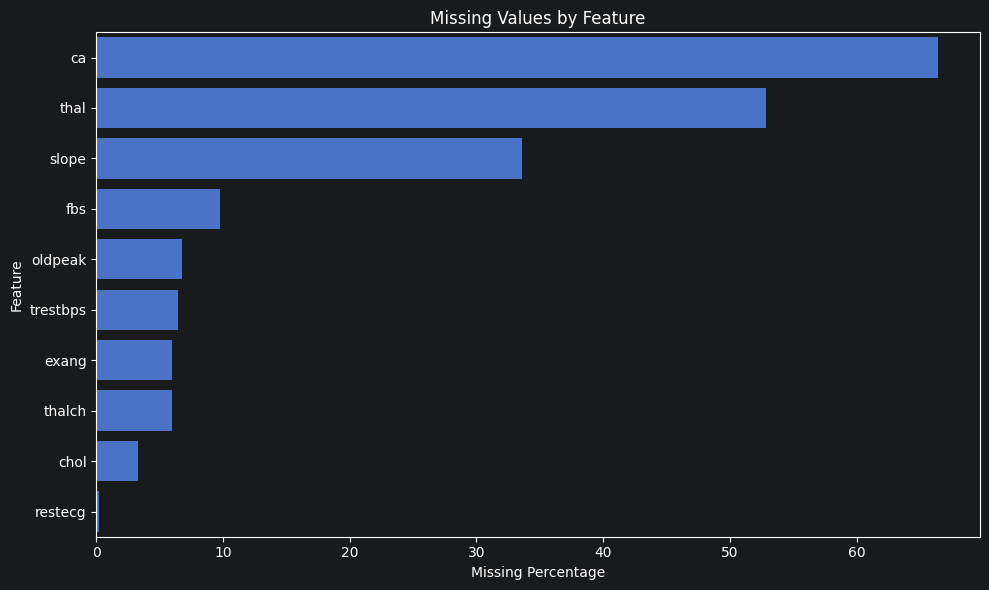

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=missing_report,
    x="missing_percent",
    y="feature",
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.tight_layout()

missing_bar_path = (
    FIGURES_DIR / "03_missing_values_bar.png"
)

plt.savefig(
    missing_bar_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [27]:
missing_by_dataset = (
    df_raw[MISSING_COLUMNS]
    .isna()
    .groupby(df_raw["dataset"])
    .mean()
    .mul(100)
)


missing_by_dataset.index.name = "dataset"

display(missing_by_dataset.round(2))

,ca,thal,slope,fbs,oldpeak,trestbps,exang,thalch,chol,restecg
dataset,,,,,,,,,,
Cleveland,1.64,0.99,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Hungary,98.98,90.44,64.51,2.73,0.00,0.34,0.34,0.34,7.85,0.34
Switzerland,95.93,42.28,13.82,60.98,4.88,1.63,0.81,0.81,0.00,0.81
VA Long Beach,99.00,83.00,51.00,3.50,28.00,28.00,26.50,26.50,3.50,0.00


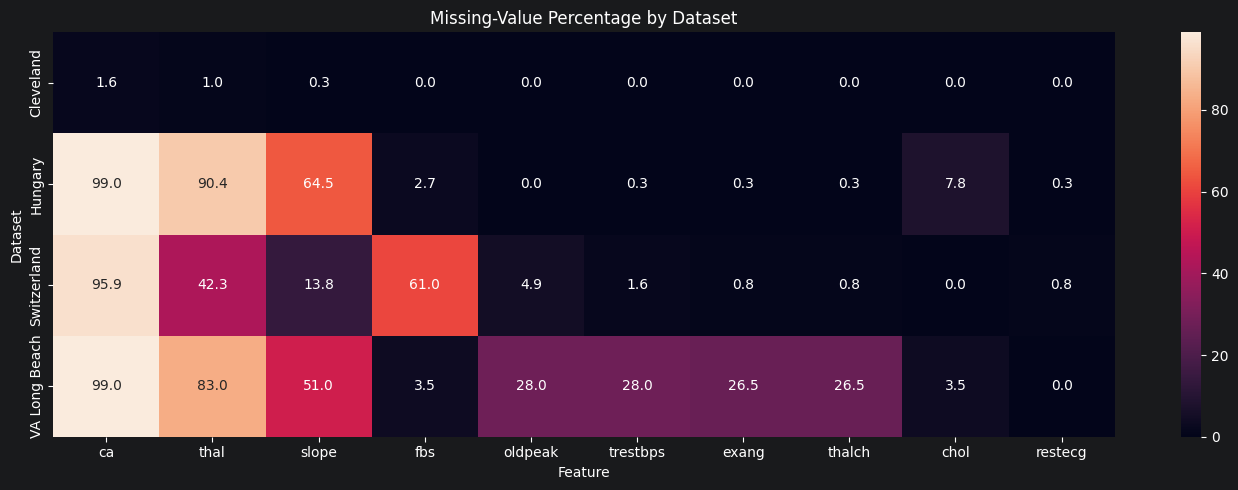

In [28]:
plt.figure(figsize=(14, 5))

sns.heatmap(
    missing_by_dataset,
    annot=True,
    fmt=".1f",
)

plt.title("Missing-Value Percentage by Dataset")
plt.xlabel("Feature")
plt.ylabel("Dataset")
plt.tight_layout()

missing_dataset_heatmap_path = (
    FIGURES_DIR
    / "03_missing_by_dataset_heatmap.png"
)

plt.savefig(
    missing_dataset_heatmap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [29]:
missing_by_target = (
    df_raw[MISSING_COLUMNS]
    .isna()
    .groupby(df_raw[TARGET_COLUMN])
    .mean()
    .mul(100)
)


missing_by_target.index.name = "target_class"

display(missing_by_target.round(2))

,ca,thal,slope,fbs,oldpeak,trestbps,exang,thalch,chol,restecg
target_class,,,,,,,,,,
0,59.85,54.50,46.96,3.41,5.11,4.87,4.87,4.87,4.62,0.00
1,78.11,60.00,25.28,15.09,5.66,4.91,4.91,4.91,2.64,0.75
2,66.97,42.20,17.43,19.27,7.34,7.34,6.42,6.42,1.83,0.00
3,65.42,42.06,24.30,12.15,14.95,14.02,12.15,12.15,0.93,0.00
4,53.57,42.86,14.29,7.14,7.14,10.71,7.14,7.14,3.57,0.00


In [30]:
def run_missingness_chi_square(
    data,
    feature,
    group_column,
):
    missing_indicator = data[feature].isna()

    contingency_table = pd.crosstab(
        data[group_column],
        missing_indicator,
    )

    if contingency_table.shape[1] < 2:
        return {
            "feature": feature,
            "group_variable": group_column,
            "chi_square": np.nan,
            "p_value": np.nan,
            "degrees_of_freedom": np.nan,
            "significant_at_0_05": False,
        }

    chi_square, p_value, degrees_of_freedom, _ = (
        chi2_contingency(contingency_table)
    )

    return {
        "feature": feature,
        "group_variable": group_column,
        "chi_square": chi_square,
        "p_value": p_value,
        "degrees_of_freedom": degrees_of_freedom,
        "significant_at_0_05": p_value < 0.05,
    }

In [31]:
missingness_test_results = []


for feature in MISSING_COLUMNS:
    missingness_test_results.append(
        run_missingness_chi_square(
            data=df_raw,
            feature=feature,
            group_column="dataset",
        )
    )

    missingness_test_results.append(
        run_missingness_chi_square(
            data=df_raw,
            feature=feature,
            group_column=TARGET_COLUMN,
        )
    )


missingness_tests = pd.DataFrame(
    missingness_test_results
)


missingness_tests = missingness_tests.sort_values(
    by=[
        "group_variable",
        "p_value",
    ],
    ascending=[
        True,
        True,
    ],
).reset_index(drop=True)


display(missingness_tests.round(6))

,feature,group_variable,chi_square,p_value,degrees_of_freedom,significant_at_0_05
0,ca,dataset,854.261116,0.000000,3,True
1,thal,dataset,572.767145,0.000000,3,True
2,fbs,dataset,423.662172,0.000000,3,True
3,slope,dataset,325.040226,0.000000,3,True
4,trestbps,dataset,198.811905,0.000000,3,True
5,exang,dataset,191.580831,0.000000,3,True
6,thalch,dataset,191.580831,0.000000,3,True
7,oldpeak,dataset,187.660704,0.000000,3,True
8,chol,dataset,33.989138,0.000000,3,True
9,restecg,dataset,3.317014,0.345282,3,False


In [32]:
dataset_tests = missingness_tests[
    missingness_tests["group_variable"] == "dataset"
].copy()

target_tests = missingness_tests[
    missingness_tests["group_variable"] == TARGET_COLUMN
].copy()


print("Significant associations with dataset:")

display(
    dataset_tests[
        dataset_tests["significant_at_0_05"]
    ][
        [
            "feature",
            "chi_square",
            "p_value",
        ]
    ].round(6)
)


print("Significant associations with target:")

display(
    target_tests[
        target_tests["significant_at_0_05"]
    ][
        [
            "feature",
            "chi_square",
            "p_value",
        ]
    ].round(6)
)

Significant associations with dataset:


,feature,chi_square,p_value
0,ca,854.261116,0.0
1,thal,572.767145,0.0
2,fbs,423.662172,0.0
3,slope,325.040226,0.0
4,trestbps,198.811905,0.0
5,exang,191.580831,0.0
6,thalch,191.580831,0.0
7,oldpeak,187.660704,0.0
8,chol,33.989138,0.0


Significant associations with target:


,feature,chi_square,p_value
10,slope,62.705703,0.000000
11,fbs,39.413025,0.000000
12,ca,26.322529,0.000027
13,thal,16.969722,0.001959
14,trestbps,13.973614,0.007380
15,oldpeak,13.784070,0.008017


In [33]:
NUMERIC_MISSING_FEATURES = [
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
]


numeric_imputation_rows = []


for feature in NUMERIC_MISSING_FEATURES:
    original_series = df_raw[feature]

    mean_value = original_series.mean()
    median_value = original_series.median()

    mean_imputed_series = original_series.fillna(
        mean_value
    )

    median_imputed_series = original_series.fillna(
        median_value
    )

    numeric_imputation_rows.append(
        {
            "feature": feature,
            "missing_count": int(
                original_series.isna().sum()
            ),
            "missing_percent": (
                original_series.isna().mean() * 100
            ),
            "mean_fill_value": mean_value,
            "median_fill_value": median_value,
            "original_mean": original_series.mean(),
            "original_median": original_series.median(),
            "original_std": original_series.std(ddof=1),
            "std_after_mean_imputation": (
                mean_imputed_series.std(ddof=1)
            ),
            "std_after_median_imputation": (
                median_imputed_series.std(ddof=1)
            ),
            "mean_after_mean_imputation": (
                mean_imputed_series.mean()
            ),
            "mean_after_median_imputation": (
                median_imputed_series.mean()
            ),
        }
    )


numeric_imputation_comparison = pd.DataFrame(
    numeric_imputation_rows
)


display(
    numeric_imputation_comparison.round(3)
)

,feature,missing_count,missing_percent,mean_fill_value,median_fill_value,original_mean,original_median,original_std,std_after_mean_imputation,std_after_median_imputation,mean_after_mean_imputation,mean_after_median_imputation
0,trestbps,59,6.413,132.132,130.0,132.132,130.0,19.066,18.444,18.451,132.132,131.996
1,chol,30,3.261,199.130,223.0,199.130,223.0,110.781,108.958,109.040,199.130,199.909
2,thalch,55,5.978,137.546,140.0,137.546,140.0,25.926,25.138,25.145,137.546,137.692
3,oldpeak,62,6.739,0.879,0.5,0.879,0.5,1.091,1.054,1.058,0.879,0.853
4,ca,611,66.413,0.676,0.0,0.676,0.0,0.936,0.542,0.629,0.676,0.227


In [34]:
CATEGORICAL_MISSING_FEATURES = [
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal",
]


categorical_imputation_rows = []


for feature in CATEGORICAL_MISSING_FEATURES:
    mode_values = df_raw[feature].mode(
        dropna=True
    )

    mode_value = (
        mode_values.iloc[0]
        if not mode_values.empty
        else np.nan
    )

    categorical_imputation_rows.append(
        {
            "feature": feature,
            "missing_count": int(
                df_raw[feature].isna().sum()
            ),
            "missing_percent": (
                df_raw[feature].isna().mean() * 100
            ),
            "mode_value": mode_value,
            "unique_non_missing_values": int(
                df_raw[feature].nunique(
                    dropna=True
                )
            ),
        }
    )


categorical_imputation_candidates = pd.DataFrame(
    categorical_imputation_rows
)


display(categorical_imputation_candidates)

,feature,missing_count,missing_percent,mode_value,unique_non_missing_values
0,fbs,90,9.782609,False,2
1,restecg,2,0.217391,normal,3
2,exang,55,5.978261,False,2
3,slope,309,33.586957,flat,3
4,thal,486,52.826087,normal,3


In [35]:
missing_report.to_csv(
    TABLES_DIR / "03_missing_values_report.csv",
    index=False,
    encoding="utf-8-sig",
)

missing_by_dataset.reset_index().to_csv(
    TABLES_DIR / "03_missing_by_dataset.csv",
    index=False,
    encoding="utf-8-sig",
)

missing_by_target.reset_index().to_csv(
    TABLES_DIR / "03_missing_by_target.csv",
    index=False,
    encoding="utf-8-sig",
)

missingness_tests.to_csv(
    TABLES_DIR / "03_missingness_chi_square.csv",
    index=False,
    encoding="utf-8-sig",
)

numeric_imputation_comparison.to_csv(
    TABLES_DIR
    / "03_numeric_imputation_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

categorical_imputation_candidates.to_csv(
    TABLES_DIR
    / "03_categorical_imputation_candidates.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 3 tables saved successfully.")

Stage 3 tables saved successfully.


In [36]:
expected_missing_total = 1759

actual_missing_total = int(
    df_raw.isna().sum().sum()
)


assert actual_missing_total == expected_missing_total, (
    "The total number of missing values is unexpected."
)

assert missing_report["missing_count"].sum() == (
    expected_missing_total
), (
    "The missing-value report is inconsistent."
)

assert (
    missing_report["missing_percent"]
    .between(0, 100)
    .all()
), (
    "Missing percentages must be between 0 and 100."
)

assert (
    missingness_tests["p_value"]
    .dropna()
    .between(0, 1)
    .all()
), (
    "P-values must be between 0 and 1."
)

assert df_raw.shape == (920, 16), (
    "The original dataset was modified unexpectedly."
)


required_output_files = [
    TABLES_DIR / "03_missing_values_report.csv",
    TABLES_DIR / "03_missing_by_dataset.csv",
    TABLES_DIR / "03_missing_by_target.csv",
    TABLES_DIR / "03_missingness_chi_square.csv",
    TABLES_DIR
    / "03_numeric_imputation_comparison.csv",
    TABLES_DIR
    / "03_categorical_imputation_candidates.csv",
    FIGURES_DIR / "03_missing_values_bar.png",
    FIGURES_DIR
    / "03_missing_by_dataset_heatmap.png",
]


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 3 validation checks passed.")

All Stage 3 validation checks passed.


## Stage 4: Outlier Detection and Preliminary Handling

This stage detects potential outliers in numeric features using the
interquartile range method.

Suspicious zero values in selected features are reviewed separately.
A temporary IQR-based capping preview is created, but the original
dataset remains unchanged.

Final outlier handling will later be fitted only on the training data
to avoid data leakage.

In [37]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The dataset file was not found.\n"
        f"Checked path: {DATA_PATH}"
    )


df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()


print("Dataset loaded successfully.")
print(f"Dataset shape: {df_raw.shape}")
print(f"Project root: {PROJECT_ROOT}")

Dataset loaded successfully.
Dataset shape: (920, 16)
Project root: E:\Projects\DataMining


In [38]:
NUMERIC_FEATURES = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
]

CONTINUOUS_FEATURES = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
]

DISCRETE_NUMERIC_FEATURES = [
    "ca",
]


missing_features = [
    feature
    for feature in NUMERIC_FEATURES
    if feature not in df_raw.columns
]


if missing_features:
    raise ValueError(
        f"Required numeric features are missing: {missing_features}"
    )


print("Continuous features:")
print(CONTINUOUS_FEATURES)

print("\nDiscrete numeric features:")
print(DISCRETE_NUMERIC_FEATURES)

Continuous features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

Discrete numeric features:
['ca']


In [39]:
SUSPICIOUS_ZERO_FEATURES = [
    "trestbps",
    "chol",
]


suspicious_zero_report = pd.DataFrame(
    {
        "feature": SUSPICIOUS_ZERO_FEATURES,
        "zero_count": [
            int((df_raw[feature] == 0).sum())
            for feature in SUSPICIOUS_ZERO_FEATURES
        ],
        "zero_percent": [
            (df_raw[feature] == 0).mean() * 100
            for feature in SUSPICIOUS_ZERO_FEATURES
        ],
        "existing_missing_count": [
            int(df_raw[feature].isna().sum())
            for feature in SUSPICIOUS_ZERO_FEATURES
        ],
    }
)


display(suspicious_zero_report.round(2))

,feature,zero_count,zero_percent,existing_missing_count
0,trestbps,1,0.11,59
1,chol,172,18.70,30


In [40]:
def calculate_iqr_outliers(data, features):
    report_rows = []
    outlier_masks = {}

    for feature in features:
        non_missing_values = data[feature].dropna()

        q1 = non_missing_values.quantile(0.25)
        q3 = non_missing_values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (
            data[feature].notna()
            & (
                (data[feature] < lower_bound)
                | (data[feature] > upper_bound)
            )
        )

        outlier_masks[feature] = outlier_mask

        outlier_values = data.loc[
            outlier_mask,
            feature,
        ]

        report_rows.append(
            {
                "feature": feature,
                "available_count": int(
                    non_missing_values.shape[0]
                ),
                "missing_count": int(
                    data[feature].isna().sum()
                ),
                "Q1": q1,
                "Q3": q3,
                "IQR": iqr,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outlier_count": int(
                    outlier_mask.sum()
                ),
                "outlier_percent": (
                    outlier_mask.mean() * 100
                ),
                "minimum_outlier": (
                    outlier_values.min()
                    if not outlier_values.empty
                    else np.nan
                ),
                "maximum_outlier": (
                    outlier_values.max()
                    if not outlier_values.empty
                    else np.nan
                ),
            }
        )

    report = pd.DataFrame(report_rows)

    return report, outlier_masks

In [41]:
raw_outlier_report, raw_outlier_masks = (
    calculate_iqr_outliers(
        data=df_raw,
        features=NUMERIC_FEATURES,
    )
)


display(
    raw_outlier_report.round(3)
)

,feature,available_count,missing_count,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent,minimum_outlier,maximum_outlier
0,age,920,0,47.0,60.0,13.0,27.50,79.50,0,0.000,NaN,NaN
1,trestbps,861,59,120.0,140.0,20.0,90.00,170.00,28,3.043,0.0,200.0
2,chol,890,30,175.0,268.0,93.0,35.50,407.50,183,19.891,0.0,603.0
3,thalch,865,55,120.0,157.0,37.0,64.50,212.50,2,0.217,60.0,63.0
4,oldpeak,858,62,0.0,1.5,1.5,-2.25,3.75,16,1.739,-2.6,6.2
5,ca,309,611,0.0,1.0,1.0,-1.50,2.50,20,2.174,3.0,3.0


In [42]:
df_outlier_analysis = df_raw.copy(deep=True)


for feature in SUSPICIOUS_ZERO_FEATURES:
    df_outlier_analysis[feature] = (
        df_outlier_analysis[feature]
        .replace(0, np.nan)
    )


print("Temporary outlier-analysis dataset created.")

print(
    "Original missing values: "
    f"{int(df_raw.isna().sum().sum())}"
)

print(
    "Temporary missing values: "
    f"{int(df_outlier_analysis.isna().sum().sum())}"
)

Temporary outlier-analysis dataset created.
Original missing values: 1759
Temporary missing values: 1932


In [43]:
adjusted_outlier_report, adjusted_outlier_masks = (
    calculate_iqr_outliers(
        data=df_outlier_analysis,
        features=CONTINUOUS_FEATURES,
    )
)


display(
    adjusted_outlier_report.round(3)
)

,feature,available_count,missing_count,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent,minimum_outlier,maximum_outlier
0,age,920,0,47.0,60.00,13.00,27.500,79.500,0,0.000,NaN,NaN
1,trestbps,860,60,120.0,140.00,20.00,90.000,170.000,27,2.935,80.0,200.0
2,chol,718,202,210.0,276.75,66.75,109.875,376.875,23,2.500,85.0,603.0
3,thalch,865,55,120.0,157.00,37.00,64.500,212.500,2,0.217,60.0,63.0
4,oldpeak,858,62,0.0,1.50,1.50,-2.250,3.750,16,1.739,-2.6,6.2


In [44]:
ca_frequency = (
    df_raw["ca"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("ca_value")
    .reset_index(name="count")
)


ca_frequency["percent"] = (
    ca_frequency["count"]
    / len(df_raw)
    * 100
)


display(ca_frequency.round(2))

,ca_value,count,percent
0,0.0,181,19.67
1,1.0,67,7.28
2,2.0,41,4.46
3,3.0,20,2.17
4,NaN,611,66.41


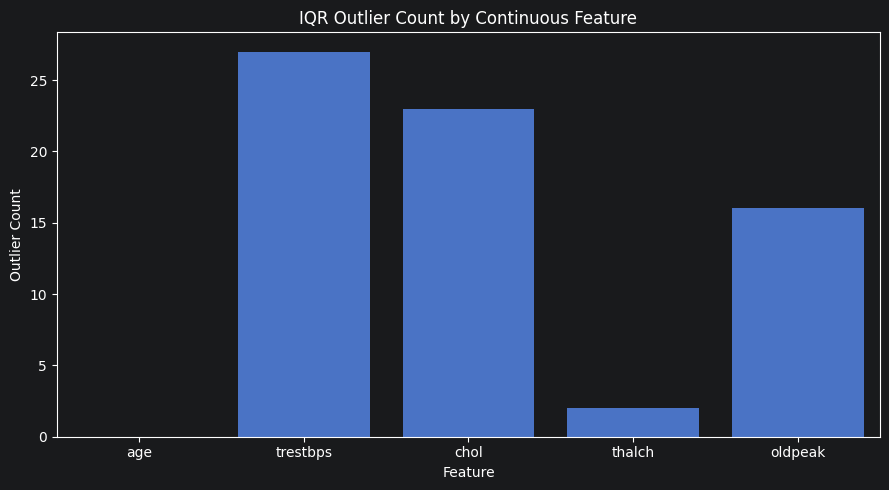

In [45]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=adjusted_outlier_report,
    x="feature",
    y="outlier_count",
)

plt.title("IQR Outlier Count by Continuous Feature")
plt.xlabel("Feature")
plt.ylabel("Outlier Count")
plt.tight_layout()

outlier_count_path = (
    FIGURES_DIR / "04_outlier_count_bar.png"
)

plt.savefig(
    outlier_count_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

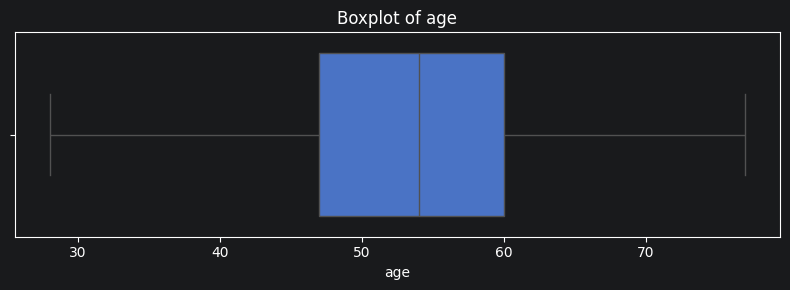

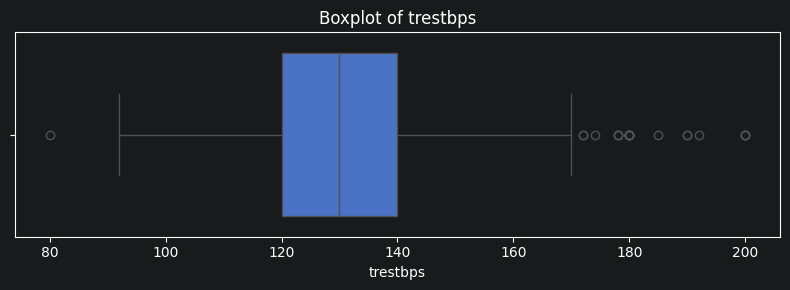

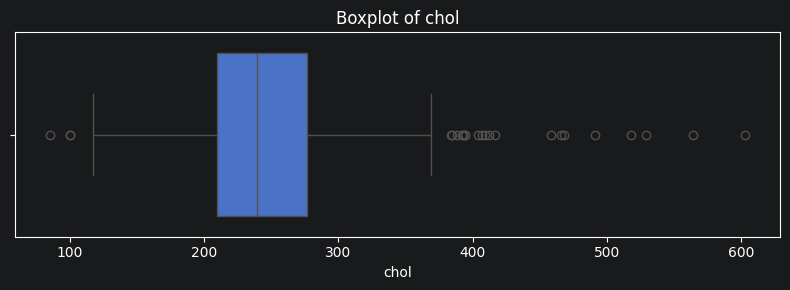

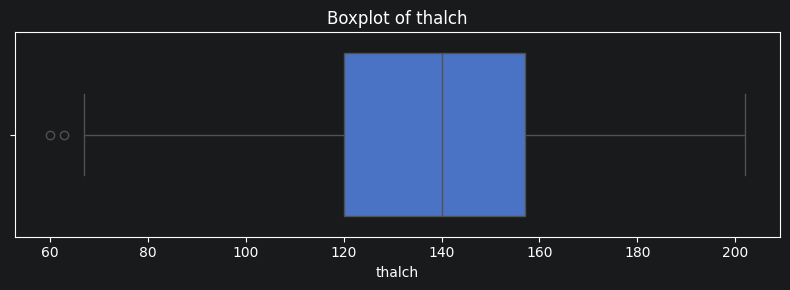

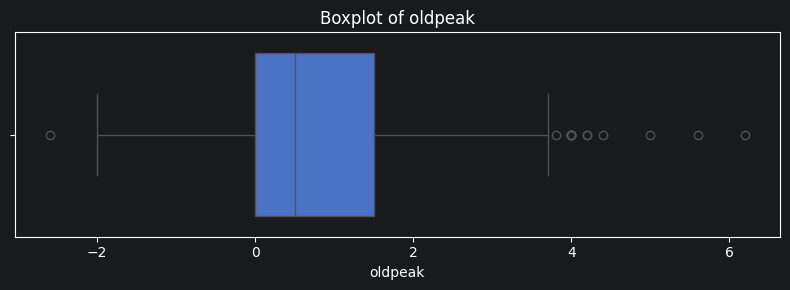

In [46]:
for feature in CONTINUOUS_FEATURES:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=df_outlier_analysis[feature],
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.tight_layout()

    figure_path = (
        FIGURES_DIR
        / f"04_boxplot_{feature}.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

In [47]:
outlier_record_frames = []


for report_row in adjusted_outlier_report.itertuples():
    feature = report_row.feature
    outlier_mask = adjusted_outlier_masks[feature]

    feature_outliers = df_outlier_analysis.loc[
        outlier_mask,
        [
            "id",
            "dataset",
            "num",
            feature,
        ],
    ].copy()

    feature_outliers = feature_outliers.rename(
        columns={
            feature: "outlier_value",
            "num": "target_class",
        }
    )

    feature_outliers["feature"] = feature
    feature_outliers["lower_bound"] = (
        report_row.lower_bound
    )
    feature_outliers["upper_bound"] = (
        report_row.upper_bound
    )

    feature_outliers["outlier_direction"] = np.where(
        feature_outliers["outlier_value"]
        < report_row.lower_bound,
        "lower",
        "upper",
    )

    outlier_record_frames.append(
        feature_outliers
    )


outlier_records = pd.concat(
    outlier_record_frames,
    ignore_index=True,
)


outlier_records = outlier_records[
    [
        "id",
        "dataset",
        "target_class",
        "feature",
        "outlier_value",
        "lower_bound",
        "upper_bound",
        "outlier_direction",
    ]
]


display(outlier_records.head(20))

,id,dataset,target_class,feature,outlier_value,lower_bound,upper_bound,outlier_direction
0,15,Cleveland,0,trestbps,172.0,90.0,170.0,upper
1,84,Cleveland,3,trestbps,180.0,90.0,170.0,upper
2,127,Cleveland,3,trestbps,200.0,90.0,170.0,upper
3,173,Cleveland,1,trestbps,174.0,90.0,170.0,upper
4,184,Cleveland,0,trestbps,178.0,90.0,170.0,upper
5,189,Cleveland,1,trestbps,192.0,90.0,170.0,upper
6,202,Cleveland,0,trestbps,180.0,90.0,170.0,upper
7,214,Cleveland,3,trestbps,178.0,90.0,170.0,upper
8,232,Cleveland,2,trestbps,180.0,90.0,170.0,upper
9,339,Hungary,0,trestbps,190.0,90.0,170.0,upper


In [48]:
df_capped_preview = (
    df_outlier_analysis.copy(deep=True)
)


capping_comparison_rows = []


for report_row in adjusted_outlier_report.itertuples():
    feature = report_row.feature

    original_series = (
        df_outlier_analysis[feature].copy()
    )

    capped_series = original_series.clip(
        lower=report_row.lower_bound,
        upper=report_row.upper_bound,
    )

    changed_mask = (
        original_series.notna()
        & capped_series.ne(original_series)
    )

    df_capped_preview[feature] = capped_series

    capping_comparison_rows.append(
        {
            "feature": feature,
            "lower_bound": report_row.lower_bound,
            "upper_bound": report_row.upper_bound,
            "changed_count": int(
                changed_mask.sum()
            ),
            "original_min": original_series.min(),
            "original_max": original_series.max(),
            "capped_min": capped_series.min(),
            "capped_max": capped_series.max(),
            "original_mean": original_series.mean(),
            "capped_mean": capped_series.mean(),
            "original_std": original_series.std(ddof=1),
            "capped_std": capped_series.std(ddof=1),
        }
    )


capping_preview = pd.DataFrame(
    capping_comparison_rows
)


display(capping_preview.round(3))

,feature,lower_bound,upper_bound,changed_count,original_min,original_max,capped_min,capped_max,original_mean,capped_mean,original_std,capped_std
0,age,27.500,79.500,0,28.0,77.0,28.000,77.000,53.511,53.511,9.425,9.425
1,trestbps,90.000,170.000,27,80.0,200.0,90.000,170.000,132.286,131.892,18.536,17.438
2,chol,109.875,376.875,23,85.0,603.0,109.875,376.875,246.833,245.031,58.527,51.756
3,thalch,64.500,212.500,2,60.0,202.0,64.500,202.000,137.546,137.553,25.926,25.906
4,oldpeak,-2.250,3.750,16,-2.6,6.2,-2.250,3.750,0.879,0.869,1.091,1.055


In [49]:
suspicious_zero_report.to_csv(
    TABLES_DIR / "04_suspicious_zero_report.csv",
    index=False,
    encoding="utf-8-sig",
)

raw_outlier_report.to_csv(
    TABLES_DIR / "04_raw_iqr_outlier_report.csv",
    index=False,
    encoding="utf-8-sig",
)

adjusted_outlier_report.to_csv(
    TABLES_DIR / "04_adjusted_iqr_outlier_report.csv",
    index=False,
    encoding="utf-8-sig",
)

outlier_records.to_csv(
    TABLES_DIR / "04_outlier_records.csv",
    index=False,
    encoding="utf-8-sig",
)

capping_preview.to_csv(
    TABLES_DIR / "04_capping_preview.csv",
    index=False,
    encoding="utf-8-sig",
)

ca_frequency.to_csv(
    TABLES_DIR / "04_ca_frequency.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 4 outputs saved successfully.")

Stage 4 outputs saved successfully.


In [50]:
assert df_raw.shape == (920, 16), (
    "The original dataset shape changed unexpectedly."
)

assert int(df_raw.isna().sum().sum()) == 1759, (
    "The original missing-value count changed unexpectedly."
)

assert (
    adjusted_outlier_report["outlier_count"] >= 0
).all(), (
    "Outlier counts cannot be negative."
)

assert (
    adjusted_outlier_report["lower_bound"]
    <= adjusted_outlier_report["upper_bound"]
).all(), (
    "Lower bounds must not exceed upper bounds."
)

assert (
    capping_preview["changed_count"]
    == adjusted_outlier_report["outlier_count"]
).all(), (
    "Capping counts do not match detected outlier counts."
)


required_output_files = [
    TABLES_DIR / "04_suspicious_zero_report.csv",
    TABLES_DIR / "04_raw_iqr_outlier_report.csv",
    TABLES_DIR / "04_adjusted_iqr_outlier_report.csv",
    TABLES_DIR / "04_outlier_records.csv",
    TABLES_DIR / "04_capping_preview.csv",
    TABLES_DIR / "04_ca_frequency.csv",
    FIGURES_DIR / "04_outlier_count_bar.png",
]


for feature in CONTINUOUS_FEATURES:
    required_output_files.append(
        FIGURES_DIR / f"04_boxplot_{feature}.png"
    )


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 4 validation checks passed.")

All Stage 4 validation checks passed.
